# Surrogate Model & Exploration Saturation Metric

A Random Forest surrogate trained on completed W&B runs to:
1. **Predict** expected scores for unexplored hyperparameter configurations
2. **Quantify exploration saturation** (ESM) — when to stop exploring a sub-space

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

from src.visualization import set_themes
from IPython.display import Markdown

from typing import List

set_themes()
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

Define the target metric, UCB exploration weight (β), and the discrete hyperparameter space to enumerate over.

In [2]:
run_summary_file = "wandb/summary.parquet"

# Target metric to predict
target_metric = "best:epoch/test_recall@20"

# UCB exploration weight — shared with the downstream UCB search feature
beta = 1.0

# Hyperparameter columns to use as surrogate features.
# parameter_space (the list of discrete values per column) is derived automatically
# from completed runs in the Data Loading step below.
feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [3]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

# Log-transform regularization columns in the raw runs too, so parameter_space
# is derived in log-space (matching the transformed full_dataframe below).
LOG_SENTINEL = -15.0
for reg_col in ["l1_regularization", "l2_regularization"]:
    experiment_runs = experiment_runs.with_columns(
        pl.when(pl.col(reg_col) > 0)
        .then(pl.col(reg_col).log(base=10))
        .otherwise(LOG_SENTINEL)
        .alias(reg_col)
    )

# Derive parameter_space from unique observed values per feature column
parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

experiment_runs.select(
    pl.col("run_id"),
    pl.col("run_name"),
    *[pl.col(c) for c in feature_names],
    pl.col(target_metric),
)[:10]

Loaded 3,382 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [-15.0, -10.0, -8.999999999999998, -8.0, -7.0, -5.999999999999999, -5.0, -3.999999999999999, -2.9999999999999996, -1.9999999999999996]
  l2_regularization: [-15.0, -10.0, -8.999999999999998, -8.0, -7.0, -5.999999999999999, -5.0, -3.999999999999999, -2.9999999999999996, -1.9999999999999996]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


run_id,run_name,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,best:epoch/test_recall@20
str,str,i64,bool,f64,f64,f64,f64
"""o94q0juk""","""logical-sweep-1""",256,false,-15.0,-6.0,0.0,0.045531
"""4ftaae0p""","""stilted-sweep-3""",4,false,-15.0,-5.0,0.0,0.010721
"""fway5u2z""","""breezy-sweep-4""",512,false,-15.0,-4.0,0.0,0.004331
"""bphcl2xf""","""clean-sweep-2""",1024,false,-15.0,-15.0,0.0,0.042439
"""dcbj92eg""","""ruby-sweep-8""",256,false,-15.0,-8.0,0.0,0.042344
"""x17mnyw8""","""breezy-sweep-9""",8,false,-15.0,-7.0,0.0,0.04182
"""7jrm756b""","""super-sweep-10""",4,false,-15.0,-4.0,0.0,0.004188
"""lwy6xxpj""","""gallant-sweep-11""",1024,false,-15.0,-2.0,0.0,0.001654
"""08sbuv2x""","""morning-sweep-16""",2,false,-15.0,-5.0,0.0,0.008526


## Data Preparation

Extract X (hyperparameter features) and y (best checkpoint score) from the loaded runs. Rows with missing target values are dropped.

- `shuffle` is cast to float (True → 1.0, False → 0.0)
- `l1_regularization` and `l2_regularization` are **log₁₀-transformed** — the performance cliff is a clean step in log-space (`-7 → -6` for l1, `-6 → -5` for l2), making it easy for RF splits to find. Zero regularization maps to a sentinel of −15.

In [4]:
# Keep only rows that have all feature columns and the target metric
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

# Cast shuffle (boolean) to float so sklearn is happy
full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Float64))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,382
Target range:  [0.0003, 0.0509]
Target mean:   0.0215  ±  0.0192


### Run Density per Parameter Region

Before choosing a leave-one-region-out holdout, check how many runs exist per value of each feature. A good holdout region should have:
- Enough runs to make the evaluation meaningful (≥ 10)
- Cover a range of target scores (not all zeros or all best)
- Not be at the extreme of the space (otherwise the surrogate has no neighbours to generalise from)

In [5]:
# Count runs and show mean target score per unique value of each feature
for col in feature_names:
    summary = (
        full_dataframe
        .group_by(col)
        .agg(
            pl.len().alias("n_runs"),
            pl.col(target_metric).mean().alias("mean_score"),
            pl.col(target_metric).std().alias("std_score"),
            pl.col(target_metric).min().alias("min_score"),
            pl.col(target_metric).max().alias("max_score"),
        )
        .sort(col)
    )
    print(f"\n── {col} ──")
    print(summary.to_pandas().to_string(index=False))


── embedding_dimension ──
 embedding_dimension  n_runs  mean_score  std_score  min_score  max_score
                   2     338    0.013377   0.011855   0.000423   0.029102
                   4     293    0.019984   0.015847   0.000413   0.037441
                   8     276    0.023473   0.018401   0.000443   0.043039
                  16     261    0.022871   0.019505   0.000372   0.047060
                  32     273    0.023200   0.020143   0.000412   0.049034
                  64     361    0.023408   0.020532   0.000362   0.049570
                 128     487    0.022619   0.020683   0.000433   0.050581
                 256     354    0.022989   0.020303   0.000394   0.050695
                 512     336    0.021898   0.020155   0.000420   0.050881
                1024     403    0.021701   0.019833   0.000344   0.050623

── shuffle ──
 shuffle  n_runs  mean_score  std_score  min_score  max_score
     0.0    2256    0.021279   0.019683   0.000344   0.050881
     1.0    1126    

## Surrogate Model Training

Fit a `RandomForestRegressor` on all completed runs.

- **μ̂** = mean prediction across trees (expected score)
- **σ̂** = std across trees (epistemic uncertainty)

`oob_score=True` gives an out-of-bag R² estimate without needing a held-out split.

In [6]:
surrogate = RandomForestRegressor(
    n_estimators=256,
    max_features="sqrt",   # ~2 features/split; forces tree diversity so σ̂ is a meaningful uncertainty signal
    max_samples=0.5,       # each tree bootstraps 20% of runs → more distinct subsets → wider σ̂ spread
    min_samples_leaf=3,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
surrogate.fit(full_features, full_target)

print(f"OOB R²: {surrogate.oob_score_:.4f}")

OOB R²: 0.9971


## Model Evaluation — Leave-Cliff-Out

Proper holdout evaluation: train on all runs *except* those at or across the two performance cliffs, then predict on the held-out set.

The test set contains runs where:
- `l1_regularization ∈ {1e-7, 1e-6}` — the last good value and the first collapsed value of the l1 cliff
- OR `l2_regularization ∈ {1e-6, 1e-5}` — the last good value and the first collapsed value of the l2 cliff

This forces the surrogate to extrapolate across both discontinuities at once — the hardest possible test of whether it has learned the cliff structure.

Train size: 2,771  |  Test size (cliff runs): 611
Test target range: [0.0004, 0.0509]

Held-out R²:  0.1497
Held-out MAE: 0.0107


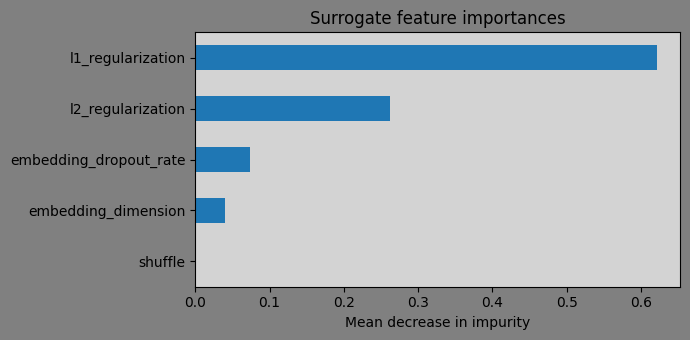

In [7]:
# Test set: runs at or across either performance cliff (values now in log10 scale)
mask_cliff = (
    full_dataframe["l1_regularization"].is_in([-7.0, -6.0])
    | full_dataframe["l2_regularization"].is_in([-6.0, -5.0])
)

train_dataframe = full_dataframe.filter(~mask_cliff)
test_dataframe  = full_dataframe.filter(mask_cliff)

train_features = train_dataframe.select(feature_names).to_numpy()
train_target   = train_dataframe[target_metric].to_numpy()
test_features  = test_dataframe.select(feature_names).to_numpy()
test_target    = test_dataframe[target_metric].to_numpy()

print(f"Train size: {len(train_dataframe):,}  |  Test size (cliff runs): {len(test_dataframe):,}")
print(f"Test target range: [{test_target.min():.4f}, {test_target.max():.4f}]")
print()

surrogate_eval = RandomForestRegressor(
    n_estimators=256,
    max_features="sqrt",
    max_samples=0.5,
    min_samples_leaf=3,
    oob_score=False,
    n_jobs=-1,
    random_state=42,
)
surrogate_eval.fit(train_features, train_target)
predicted_target = surrogate_eval.predict(test_features)

print(f"Held-out R²:  {r2_score(test_target, predicted_target):.4f}")
print(f"Held-out MAE: {mean_absolute_error(test_target, predicted_target):.4f}")

# Feature importance plot (from the full-data surrogate)
fig, ax = plt.subplots(figsize=(7, 3.5))
importances = pd.Series(surrogate_eval.feature_importances_, index=feature_names).sort_values(ascending=True)
importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Surrogate feature importances")
plt.tight_layout()
plt.show()

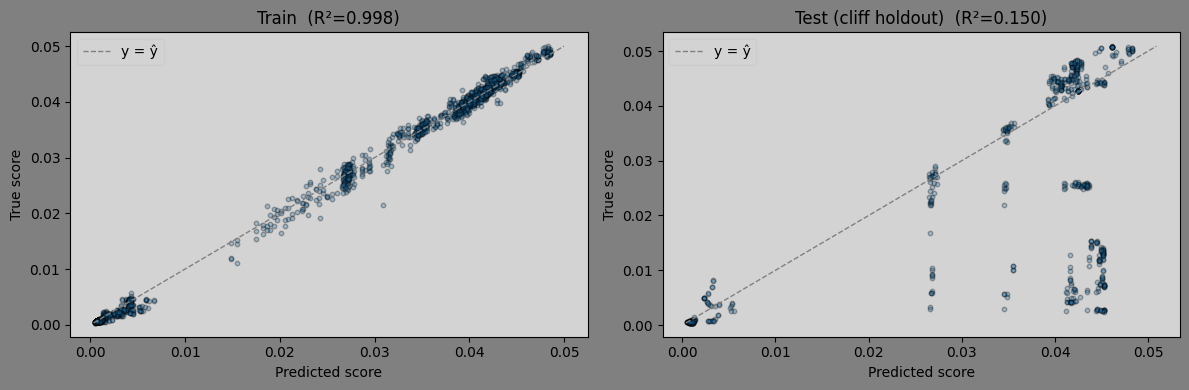

In [8]:
train_prediction = surrogate_eval.predict(train_features)
test_prediction  = surrogate_eval.predict(test_features)

axes: List[plt.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ground_truth, prediction, label in [
    (axes[0], train_target, train_prediction, "Train"),
    (axes[1], test_target,  test_prediction,  "Test (cliff holdout)"),
]:
    ax.scatter(prediction, ground_truth, alpha=0.3, s=10)
    lo = min(ground_truth.min(), prediction.min())
    hi = max(ground_truth.max(), prediction.max())
    ax.plot([lo, hi], [lo, hi], "--", linewidth=1, label="y = ŷ", color="grey")
    ax.set_xlabel("Predicted score")
    ax.set_ylabel("True score")
    ax.set_title(f"{label}  (R²={r2_score(ground_truth, prediction):.3f})")
    ax.legend()

plt.tight_layout()
plt.show()

### μ̂ and σ̂ Distributions — Train vs. Test

Comparing the predicted mean (μ̂) and uncertainty (σ̂) distributions across the train and test splits.

- **Similar μ̂ distributions** → the surrogate generalises rather than memorising
- **Higher σ̂ on test** → the model correctly signals more uncertainty on less-seen configurations

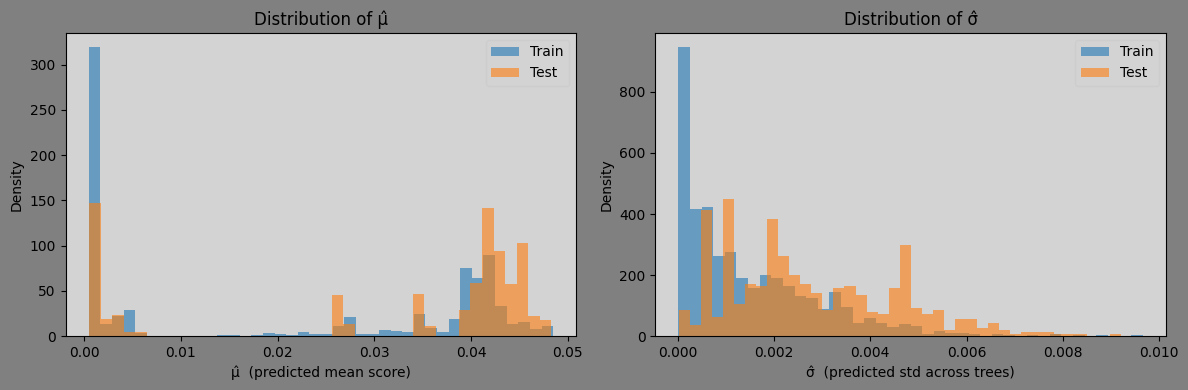

Train — μ̂: 0.0212 ± 0.0191   σ̂: 0.0015 ± 0.0015
Test  — μ̂: 0.0316 ± 0.0173   σ̂: 0.0028 ± 0.0018


In [9]:
# Compute per-tree predictions for train and test splits to get µ̂ and σ̂
train_tree_predictions = np.stack([tree.predict(train_features) for tree in surrogate_eval.estimators_], axis=0)
test_tree_predictions  = np.stack([tree.predict(test_features)  for tree in surrogate_eval.estimators_], axis=0)

mu_train    = train_tree_predictions.mean(axis=0)
sigma_train = train_tree_predictions.std(axis=0)
mu_test     = test_tree_predictions.mean(axis=0)
sigma_test  = test_tree_predictions.std(axis=0)

axes: List[plt.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# µ̂ distribution
axes[0].hist(mu_train, bins=40, alpha=0.6, density=True, label="Train")
axes[0].hist(mu_test,  bins=40, alpha=0.6, density=True, label="Test")
axes[0].set_xlabel("μ̂  (predicted mean score)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of μ̂")
axes[0].legend()

# σ̂ distribution
axes[1].hist(sigma_train, bins=40, alpha=0.6, density=True, label="Train")
axes[1].hist(sigma_test,  bins=40, alpha=0.6, density=True, label="Test")
axes[1].set_xlabel("σ̂  (predicted std across trees)")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of σ̂")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Train — μ̂: {mu_train.mean():.4f} ± {mu_train.std():.4f}   σ̂: {sigma_train.mean():.4f} ± {sigma_train.std():.4f}")
print(f"Test  — μ̂: {mu_test.mean():.4f} ± {mu_test.std():.4f}   σ̂: {sigma_test.mean():.4f} ± {sigma_test.std():.4f}")

## Full Parameter Space — Explored vs. Unexplored

Enumerate every combination in `PARAM_SPACE`, then label each cell as explored (at least one completed run exists) or unexplored. The surrogate will be applied to the unexplored cells.

In [ ]:
# Build the full grid as a DataFrame
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)

# Build a lookup key from the explored runs: round floats to avoid fp equality issues
def make_key(row: dict) -> tuple:
    return tuple(row[c] for c in feature_names)

# Aggregate explored runs: take the best observed score per unique config
explored_df = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).max().alias("best_observed_score"))
)

# Tag each grid cell as explored or not
explored_keys = set(
    tuple(row) for row in explored_df.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)

n_explored   = full_grid["explored"].sum()
n_unexplored = len(full_grid) - n_explored
coverage_pct = 100 * n_explored / len(full_grid)

print(f"Total cells:  {len(full_grid):,}")
print(f"Explored:     {n_explored:,}  ({coverage_pct:.2f}%)")
print(f"Unexplored:   {n_unexplored:,}")

In [ ]:
# Predict μ̂ and σ̂ for every unexplored cell
unexplored_df = full_grid.filter(~pl.col("explored"))
X_unexplored = unexplored_df.select(feature_names).with_columns(
    pl.col("shuffle").cast(pl.Float64)
).to_numpy()

# Collect per-tree predictions to compute mean and std
tree_preds = np.stack([tree.predict(X_unexplored) for tree in surrogate.estimators_], axis=0)  # (n_trees, n_cells)
mu_hat   = tree_preds.mean(axis=0)
sigma_hat = tree_preds.std(axis=0)

unexplored_df = unexplored_df.with_columns([
    pl.Series("mu_hat",    mu_hat),
    pl.Series("sigma_hat", sigma_hat),
    pl.Series("ucb",       mu_hat + beta * sigma_hat),
])

print(f"Predictions computed for {len(unexplored_df):,} unexplored cells")
unexplored_df.select("mu_hat", "sigma_hat", "ucb").describe()

## Exploration Saturation Metric (ESM)

$$\text{ESM} = \frac{\mu_{\text{best, observed}}}{\hat{\mu}_{\text{max}} + \beta \cdot \hat{\sigma}_{\text{max}}} \times 100\%$$

- **Numerator** — best score actually seen in completed runs
- **Denominator** — UCB upper bound on what the surrogate believes is still achievable

A higher ESM means the sub-space is more saturated. 99.99% (4 nines) is the suggested stop threshold.

In [ ]:
mu_best_observed = explored_df["best_observed_score"].max()

# UCB of the best unexplored cell
best_ucb_idx   = unexplored_df["ucb"].arg_max()
mu_hat_max     = unexplored_df["mu_hat"][best_ucb_idx]
sigma_hat_max  = unexplored_df["sigma_hat"][best_ucb_idx]
ucb_max        = mu_hat_max + beta * sigma_hat_max

esm = (mu_best_observed / ucb_max) * 100

# Count "nines" after the decimal
nines = 0
remainder = esm
while remainder >= 9 * (10 ** (-nines - 1)) + (1 - 10 ** (-nines)):
    nines += 1
    if nines > 10:
        break

print(f"Best observed score (μ_best): {mu_best_observed:.6f}")
print(f"Best unexplored UCB:  μ̂={mu_hat_max:.6f}  σ̂={sigma_hat_max:.6f}  UCB={ucb_max:.6f}")
print()
print(f"ESM = {esm:.6f}%  ({nines} nines)")

# Quick interpretation
thresholds = [(99.99, "4 nines — essentially saturated, move on"),
              (99.9,  "3 nines — marginal gain remaining"),
              (99.0,  "2 nines — modest gain remaining"),
              (90.0,  "1 nine  — substantial gain likely remaining")]
for threshold, label in thresholds:
    if esm >= threshold:
        print(f"  → {label}")
        break
else:
    print("  → Below 90% — early exploration stage")

## Coverage at Percentile

$$\text{Coverage}_{p} = \frac{|\{x \in \text{explored} : \hat{\mu}(x) \geq p\text{-th percentile}\}|}{|\{x \in \text{all} : \hat{\mu}(x) \geq p\text{-th percentile}\}|}$$

Using p=75: *"what fraction of the top-25% predicted configurations have been tried?"*

In [ ]:
# Predict μ̂ for the full grid (explored + unexplored) to compute coverage
X_full = full_grid.select(feature_names).with_columns(
    pl.col("shuffle").cast(pl.Float64)
).to_numpy()
mu_full = surrogate.predict(X_full)

full_grid_with_mu = full_grid.with_columns(pl.Series("mu_hat", mu_full))

def coverage_at_percentile(grid: pl.DataFrame, p: float = 75.0) -> float:
    """Fraction of top-(100-p)% predicted configs that have been explored."""
    threshold = np.percentile(grid["mu_hat"].to_numpy(), p)
    top_cells   = grid.filter(pl.col("mu_hat") >= threshold)
    n_top_explored = top_cells["explored"].sum()
    return 100.0 * n_top_explored / len(top_cells)

for p in [50, 75, 90, 95]:
    cov = coverage_at_percentile(full_grid_with_mu, p)
    print(f"Coverage at p={p:2d}  (top {100-p:2d}% predicted configs):  {cov:.2f}%")

## Stop Condition & Top Unexplored Configurations

Stop exploring this sub-space when **both** hold:
- ESM ≥ 99.9% (3 nines)
- Coverage at p=75 ≥ 80%

Also display the top unexplored cells ranked by UCB — these are the next best candidates to run.

In [ ]:
ESM_STOP_THRESHOLD      = 99.9   # 3 nines
COVERAGE_STOP_THRESHOLD = 80.0   # percent
COVERAGE_PERCENTILE     = 75

coverage_75 = coverage_at_percentile(full_grid_with_mu, COVERAGE_PERCENTILE)

esm_met      = esm >= ESM_STOP_THRESHOLD
coverage_met = coverage_75 >= COVERAGE_STOP_THRESHOLD
should_stop  = esm_met and coverage_met

print("=" * 50)
print(f"  ESM:          {esm:.4f}%   (threshold ≥ {ESM_STOP_THRESHOLD}%)  {'✓' if esm_met else '✗'}")
print(f"  Coverage@75:  {coverage_75:.2f}%    (threshold ≥ {COVERAGE_STOP_THRESHOLD}%)  {'✓' if coverage_met else '✗'}")
print("=" * 50)
print(f"  → {'STOP — sub-space saturated.' if should_stop else 'CONTINUE exploration.'}")
print("=" * 50)

In [ ]:
# Top unexplored configurations ranked by UCB
top_unexplored = (
    unexplored_df
    .sort("ucb", descending=True)
    .head(20)
    .select([*feature_names, "mu_hat", "sigma_hat", "ucb"])
)
top_unexplored